## Title :
Exercise: Simple kNN Regression

## Description :
The goal of this exercise is to **re-create the plots** given below. You would have come across these graphs in the lecture as well.

<img src="https://github.com/Harvard-IACS/2021-CS109A/blob/master/docs/lectures/lecture03/fig/fig2.png?raw=1" style="width: 500px;">
<img src="https://github.com/Harvard-IACS/2021-CS109A/blob/master/docs/lectures/lecture03/fig/fig3.png?raw=1" style="width: 500px;">

## Data Description:

## Instructions:

<u>Part 1:</u> KNN by hand for k=1
- Read the Advertisement data.
- Get a subset of the data from row 5 to row 13.
- Apply the kNN algorithm by hand and plot the first graph as given above.

<u>Part 2:</u> Using sklearn package
- Read the Advertisement dataset.
- Split the data into train and test sets using the `train_test_split()` function.
- Set `k_list` as the possible k values ranging from 1 to 70.
- For each value of `k` in `k_list`:
    - Use `sklearn KNearestNeighbors()` to fit train data.
    - Predict on the test data.
    - Use the helper code to get the second plot above for k=1,10,70.



## Hints:

<a href="https://numpy.org/doc/stable/reference/generated/numpy.argsort.html" target="_blank">np.argsort()</a>
Returns the indices that would sort an array.

<a href="https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.iloc.html" target="_blank">df.iloc[]</a>
Returns a subset of the dataframe that is contained in the column range passed as the argument.

<a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html" target="_blank">plt.plot()</a>
Plot y versus x as lines and/or markers.

<a href="https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.values.html" target="_blank">df.values</a>
Returns a Numpy representation of the DataFrame.

<a href="https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.idxmin.html" target="_blank">pd.idxmin()</a>
Returns index of the first occurrence of minimum over requested axis.

<a href="http://pageperso.lif.univ-mrs.fr/~francois.denis/IAAM1/numpy-html-1.14.0/reference/generated/numpy.ndarray.min.html" target="_blank">np.min()</a>
Returns the minimum along a given axis.

<a href="https://numpy.org/doc/stable/reference/generated/numpy.ndarray.max.html" target="_blank">np.max()</a>
Returns the maximum along a given axis.

<a href="https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#sklearn.neighbors.KNeighborsRegressor.fit" target="_blank">model.fit()</a>
Fit the k-nearest neighbors regressor from the training dataset.

<a href="https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#sklearn.neighbors.KNeighborsRegressor.predict" target="_blank">model.predict()</a>
Predict the target for the provided data.

<a href="https://numpy.org/devdocs/reference/generated/numpy.zeros.html" target="_blank">np.zeros()</a>
Returns a new array of given shape and type, filled with zeros.

<a href="http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html" target="_blank">train_test_split(X,y)</a>
Split arrays or matrices into random train and test subsets.

<a href="https://numpy.org/doc/stable/reference/generated/numpy.linspace.html" target="_blank">np.linspace()</a>
Returns evenly spaced numbers over a specified interval.

<a href="https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html" target="_blank">KNeighborsRegressor(n_neighbors=k_value)</a>
Regression-based on k-nearest neighbors.

**Note:** This exercise is auto-graded, hence please remember to set all the parameters to the values mentioned in the scaffold before marking.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
%matplotlib inline


In [2]:
# Read the data from the file "Advertising.csv"
filename = '/content/Advertising.csv'
df_adv = pd.read_csv(filename)


In [3]:
# Take a quick look of the dataset
df_adv.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## Part 1: KNN by hand for $k=1$

In [4]:
# Get a subset of the data i.e. rows 5 to 13
# Use the TV column as the predictor
x_true = df_adv.TV.iloc[5:13]

# Use the Sales column as the response
y_true = df_adv.Sales.iloc[5:13]

# Sort the data to get indices ordered from lowest to highest TV values
idx = np.argsort(x_true).values

# Get the predictor data in the order given by idx above
x_true  = x_true.iloc[idx].values

# Get the response data in the order given by idx above
y_true  = y_true.iloc[idx].values


In [5]:
### edTest(test_findnearest) ###
# Define a function that finds the index of the nearest neighbor
# and returns the value of the nearest neighbor.
# Note that this is just for k = 1 where the distance function is
# simply the absolute value.

def find_nearest(array,value):

    # Hint: To find idx, use .idxmin() function on the series
    idx = pd.Series(np.abs(array-value)).idxmin()

    # Return the nearest neighbor index and value
    return idx, array[idx]


In [6]:
# Create some synthetic x-values (might not be in the actual dataset)
x = np.linspace(np.min(x_true), np.max(x_true))

# Initialize the y-values for the length of the synthetic x-values to zero
y = np.zeros((len(x)))


In [7]:
# Apply the KNN algorithm to predict the y-value for the given x value
for i, xi in enumerate(x):

    # Get the Sales values closest to the given x value
    y[i] = y[find_nearest(x, xi )[0]]


### Plotting the data

Text(0, 0.5, 'Sales in $1000')

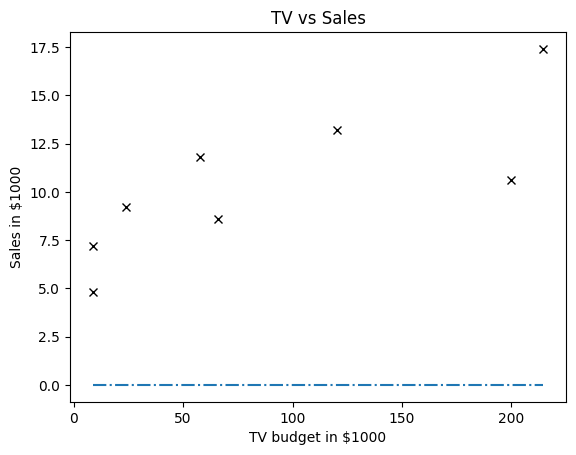

In [9]:
import matplotlib.pyplot as plt

# Plot the synthetic data along with the predictions
plt.plot(x, y, '-.')

# Plot the original data using black x's.
plt.plot(x_true, y_true, 'kx')

# Set the title and axis labels
plt.title('TV vs Sales')
plt.xlabel('TV budget in $1000')
plt.ylabel('Sales in $1000')


## Part 2: KNN for $k\ge1$ using sklearn

In [11]:
# Read the data from the file "Advertising.csv"
data_filename = 'Advertising.csv'
df = pd.read_csv(data_filename)

# Set 'TV' as the 'predictor variable'
x = df[['TV']]

# Set 'Sales' as the response variable 'y'
y = df['Sales']


In [13]:
### edTest(test_shape) ###

# Split the dataset in training and testing with 60% training set
# and 40% testing set with random state = 42
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.6,random_state=42)


In [15]:
### edTest(test_nums) ###

# Choose the minimum k value based on the instructions given on the left
k_value_min = 1

# Choose the maximum k value based on the instructions given on the left
k_value_max = 70


# Create a list of integer k values betwwen k_value_min and k_value_max using linspace
k_list = np.linspace(k_value_min, k_value_max, 70)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


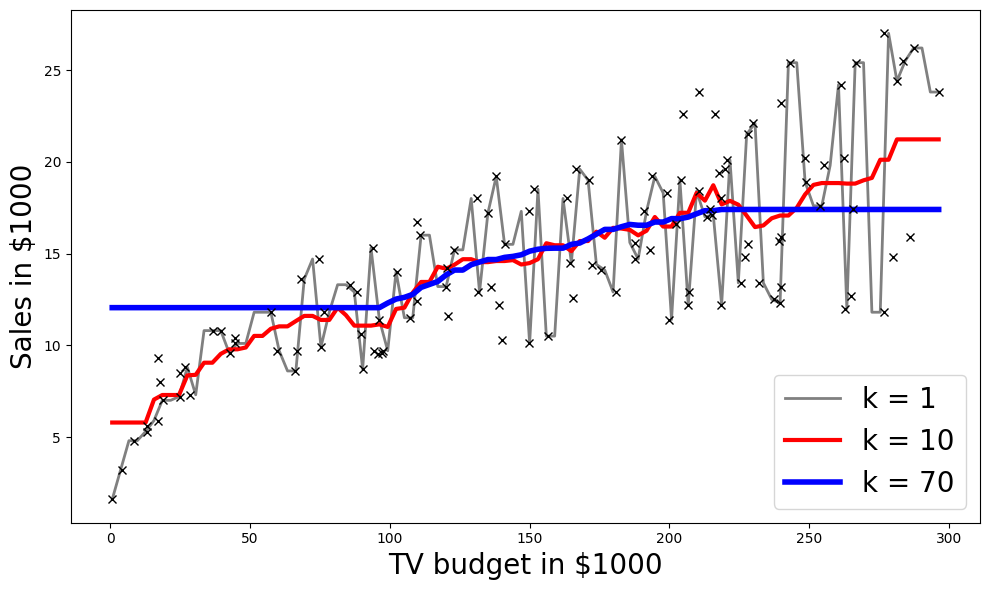

In [17]:
# Set the grid to plot the values
fig, ax = plt.subplots(figsize=(10,6))

# Variable used to alter the linewidth of each plot
j=0

# Loop over all the k values
for k_value in k_list:

    # Creating a kNN Regression model
    model = KNeighborsRegressor(n_neighbors=int(k_value))

    # Fitting the regression model on the training data
    model.fit(x_train, y_train)

    # Use the trained model to predict on the test data
    y_pred = model.predict(x_test)

    # Helper code to plot the data along with the model predictions
    colors = ['grey','r','b']
    if k_value in [1,10,70]:
        xvals = np.linspace(x.min(),x.max(),100)
        ypreds = model.predict(xvals)
        ax.plot(xvals, ypreds,'-',label = f'k = {int(k_value)}',linewidth=j+2,color = colors[j])
        j+=1

ax.legend(loc='lower right',fontsize=20)
ax.plot(x_train, y_train,'x',label='train',color='k')
ax.set_xlabel('TV budget in $1000',fontsize=20)
ax.set_ylabel('Sales in $1000',fontsize=20)
plt.tight_layout()


#### ⏸ In the plotting code above, re-run `ax.plot(x_train, y_train,'x',label='train',color='k')` with `x_test` and `y_test` instead. According to you, which k value is the best and why?

In [18]:
### edTest(test_chow1) ###
# Type your answer within in the quotes given
answer1 = '___'
